In [50]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone
from extractor.alp_extractor import ALPExtractor

In [51]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp500 = market.retrieve("sp500")
market.disconnect()
alp = ALPExtractor()

In [52]:
holding_period = 65
tickers = sp500["ticker"].values
positions = 10
training_year = datetime.now().year - 10
today = datetime.now()
weekday = today.weekday() - 1 if today.weekday() != 0 else 4
week = today.isocalendar()[1] if today.weekday() != 0 else today.isocalendar()[1] - 1
week_mod = int(week % (holding_period/5))
print(week_mod,week)

11 50


In [53]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        # ticker_prices = processor.column_date_processing(alp.prices(ticker,start,end))
        ticker_prices.sort_values("date",inplace=True)
        simulation = ticker_prices.copy()
        simulation.sort_values("date",inplace=True)
        simulation["historical_return"] = (simulation["adjclose"] - simulation["adjclose"].shift(100)) / simulation["adjclose"].shift(100)
        simulation["historical_volatility"] = simulation["adjclose"].rolling(100).std() / simulation["adjclose"].rolling(100).mean()
        simulation["historical_return_to_risk"] = simulation["historical_return"] / simulation["historical_volatility"]
        simulation["volatility"] = (simulation["adjclose"].rolling(holding_period).std() / simulation["adjclose"].rolling(holding_period).mean())
        simulation["current_return"] = (simulation["adjclose"] - simulation["adjclose"].shift(holding_period)) / simulation["adjclose"].shift(holding_period)
        simulation["return_to_risk"] = simulation["current_return"] / simulation["volatility"]
        simulation["expected_return"] = simulation["historical_return_to_risk"] * simulation["volatility"]
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"] + timedelta(days=int(holding_period /5) * 7)
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"]
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  13%|█▎        | 65/503 [00:10<00:52,  8.34it/s]

'date'


model_prep:  16%|█▌        | 81/503 [00:12<00:50,  8.36it/s]

'date'


model_prep: 100%|██████████| 503/503 [01:18<00:00,  6.40it/s]

'date'


In [54]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp500,on="ticker")
fed.connect()
bench = fed.retrieve("sp500")
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
fed.disconnect()
trades = sim[sim["weekday"]==weekday].copy()
trades = trades[trades["week"] % int(holding_period/5) == week_mod]
trades = processor.column_date_processing(trades)

In [55]:
## backtest
valuation_methods = ["historical_return"
                     ,"historical_volatility"
                     ,"historical_return_to_risk"
                     ,"volatility"
                     ,"current_return"
                     ,"return_to_risk"
                     ,"expected_return"]
reports = []
for valuation_method in tqdm(valuation_methods):
    try:
        iteration_trades = trades.copy().sort_values(valuation_method,ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
        portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
        portfolio.sort_values("date",inplace=True)
        portfolio["year"] = [x.year for x in portfolio["date"]]
        portfolio = portfolio[(portfolio["date"]<portfolio["date"].max()) & (portfolio["year"]>=training_year)]
        portfolio["return"] = portfolio["return"] * (1/positions) + 1
        portfolio["cumulative_return"] = portfolio["return"].cumprod()
        portfolio = processor.column_date_processing(portfolio)
        portfolio = processor.merge(portfolio,bench.copy(),on="date")
        portfolio.dropna(inplace=True)
        portfolio["bench_cum_return"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1
        portfolio["beta"] = portfolio["cumulative_return"].cov(portfolio["value"])
        portfolio["treynor"] = portfolio["cumulative_return"] / portfolio["beta"]
        portfolio["excess_return"] = portfolio["cumulative_return"] - portfolio["bench_cum_return"]
        portfolio["valuation_method"] = valuation_method
        reports.append(portfolio[["valuation_method","excess_return"]].tail(1))
    except Exception as e:
        print(str(e))
        continue

100%|██████████| 7/7 [00:01<00:00,  4.03it/s]


In [56]:
report = pd.concat(reports)

In [57]:
report.sort_values("excess_return",ascending=False)

,valuation_method,excess_return
38,historical_volatility,21.190219
38,expected_return,18.363985
38,historical_return,18.154890
38,volatility,17.152378
38,current_return,10.382299
38,historical_return_to_risk,1.710521
38,return_to_risk,1.589914


In [58]:
valuation_method = "historical_volatility"

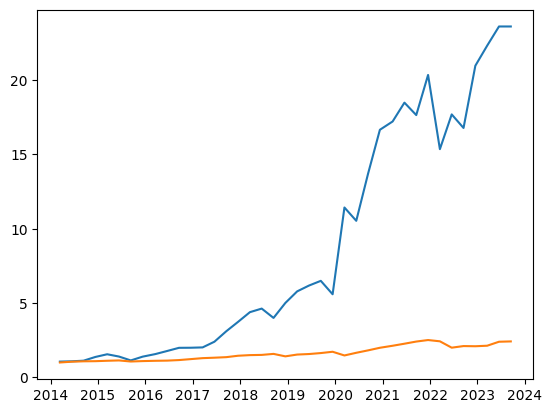

In [59]:
iteration_trades = trades.copy().sort_values(valuation_method,ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
iteration_trades = iteration_trades[["date","sell_date","ticker","adjclose",valuation_method,"return"]]
portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio["year"] = [x.year for x in portfolio["date"]]
portfolio = portfolio[(portfolio["date"]<portfolio["date"].max()) & (portfolio["year"]>=training_year)]
portfolio["return"] = portfolio["return"] * (1/positions) + 1
portfolio["cumulative_return"] = portfolio["return"].cumprod()
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench.copy(),on="date")
portfolio.dropna(inplace=True)
portfolio["bench_cum_return"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1
portfolio["excess_return"] = portfolio["cumulative_return"] - portfolio["bench_cum_return"]
recommendations = iteration_trades[["date","sell_date","ticker","adjclose",valuation_method]].sort_values(["date"]).tail(positions)
plt.plot(portfolio["date"].values,portfolio["cumulative_return"].values)
plt.plot(portfolio["date"].values,portfolio["bench_cum_return"].values)
plt.show()

In [60]:
portfolio.sort_values("return",ascending=False).head(5)

,date,return,year,cumulative_return,quarter,month,week,weekday,realtime_start,realtime_end,value,bench_cum_return,excess_return
24,2020-03-13 00:00:00+00:00,2.044562,2020,11.427665,1,3,11,4,2023-12-10,2023-12-10,2711.02,1.472476,9.955189
26,2020-09-11 00:00:00+00:00,1.301266,2020,13.704992,3,9,37,4,2023-12-10,2023-12-10,3340.97,1.814630,11.890362
14,2017-09-15 00:00:00+00:00,1.292861,2017,3.100224,3,9,37,4,2023-12-10,2023-12-10,2500.23,1.357987,1.742237
19,2018-12-14 00:00:00+00:00,1.251712,2018,5.004666,4,12,50,4,2023-12-10,2023-12-10,2599.95,1.412149,3.592517
35,2022-12-16 00:00:00+00:00,1.249592,2022,20.966845,4,12,50,4,2023-12-10,2023-12-10,3852.36,2.092389,18.874456


In [61]:
iteration_trades.sort_values("return",ascending=False).head(10)

,date,sell_date,ticker,adjclose,historical_volatility,return
164,2020-03-13 00:00:00+00:00,2020-06-12 00:00:00+00:00,CZR,18.220000,0.191360,1.960087
123,2020-03-13 00:00:00+00:00,2020-06-12 00:00:00+00:00,APA,7.636031,0.209031,1.676283
15,2020-03-13 00:00:00+00:00,2020-06-12 00:00:00+00:00,TSLA,36.441333,0.370767,1.206687
168,2020-03-13 00:00:00+00:00,2020-06-12 00:00:00+00:00,FANG,22.949620,0.189732,1.148398
150,2020-03-13 00:00:00+00:00,2020-06-12 00:00:00+00:00,RCL,32.330000,0.196678,1.087508
311,2021-06-18 00:00:00+00:00,2021-09-17 00:00:00+00:00,MRNA,199.190000,0.147878,1.084326
92,2019-03-15 00:00:00+00:00,2019-06-14 00:00:00+00:00,ENPH,9.050000,0.227189,0.944157
18,2020-03-13 00:00:00+00:00,2020-06-12 00:00:00+00:00,ENPH,32.860000,0.358263,0.922040
125,2020-03-13 00:00:00+00:00,2020-06-12 00:00:00+00:00,NCLH,11.100000,0.207922,0.915905
63,2017-06-16 00:00:00+00:00,2017-09-15 00:00:00+00:00,ENPH,0.770000,0.255666,0.887500


In [62]:
recommendations

,date,sell_date,ticker,adjclose,historical_volatility
19,2023-12-15 00:00:00+00:00,2024-03-15 00:00:00+00:00,SEDG,97.12,0.358097
212,2023-12-15 00:00:00+00:00,2024-03-15 00:00:00+00:00,ENPH,123.92,0.173103
141,2023-12-15 00:00:00+00:00,2024-03-15 00:00:00+00:00,PODD,206.97,0.201424
88,2023-12-15 00:00:00+00:00,2024-03-15 00:00:00+00:00,ALGN,255.01,0.229416
112,2023-12-15 00:00:00+00:00,2024-03-15 00:00:00+00:00,PAYC,202.77,0.213680
173,2023-12-15 00:00:00+00:00,2024-03-15 00:00:00+00:00,ALB,147.06,0.187384
116,2023-12-15 00:00:00+00:00,2024-03-15 00:00:00+00:00,ILMN,127.10,0.211578
267,2023-12-15 00:00:00+00:00,2024-03-15 00:00:00+00:00,DG,129.98,0.159855
124,2023-12-15 00:00:00+00:00,2024-03-15 00:00:00+00:00,FMC,59.51,0.208258
256,2023-12-15 00:00:00+00:00,2024-03-15 00:00:00+00:00,MRNA,86.01,0.162810


In [63]:
db.connect()
db.drop('portfolio')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",iteration_trades)
db.store("recommendations",recommendations)
db.disconnect()